In [32]:
import xarray as xr
from dask.distributed import Client
from tqdm.notebook import tqdm
import cartopy.crs as ccrs
import numpy as np
# client = Client(n_workers=8, threads_per_worker=1, memory_limit='6GB')
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:35505/status,
Dashboard: http://127.0.0.1:35505/status,Workers: 8
Total threads: 8,Total memory: 44.70 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:34309,Workers: 0
Dashboard: http://127.0.0.1:35505/status,Total threads: 0
Started: 43 minutes ago,Total memory: 0 B
Comm: tcp://127.0.0.1:38175,Total threads: 1
Dashboard: http://127.0.0.1:41901/status,Memory: 5.59 GiB
Nanny: tcp://127.0.0.1:44707,


In [2]:
import xarray as xr
from dask.distributed import Client

# Uncomment to use parallel workers
# client = Client(n_workers=4, threads_per_worker=1, memory_limit='4GB')

# Generate file patterns for years 1979-1988 and all 12 months
file_pattern = '/Data/gfi/share/era5/pl/ea.ans.*.850.v.nc'

# Open all matching files at once with dask backend
all_ds_out = xr.open_mfdataset(
    file_pattern,
    combine='nested',
    concat_dim='time',
    preprocess=lambda ds: ds.drop_vars([c for c in ['lev', 'plev'] if c in ds.coords]).squeeze(),
    parallel=True,
    chunks={'time': 365}  # Optimize chunk size for your data
)

# Apply spatial selection once to entire dataset
ds_final = all_ds_out.sel(
    longitude=slice(-60, 120), 
    latitude=slice(30, -30)
).resample(time='1D').mean()

# Compute when ready (or save for later computation)
ds_final.to_netcdf('/Data/gfi/users/rogui7909/data/AfricaPrecip/features/v850.nc')

In [8]:
import xarray as xr
from dask.distributed import Client

# Uncomment to use parallel workers
# client = Client(n_workers=4, threads_per_worker=1, memory_limit='4GB')

# Generate file patterns for years 1979-1988 and all 12 months
file_pattern = '/Data/gfi/share/era5/sfc/ea.ans.*.sfc.msl.nc'

# Open all matching files at once with dask backend
all_ds_out = xr.open_mfdataset(
    file_pattern,
    combine='nested',
    concat_dim='time',
    preprocess=lambda ds: ds.drop_vars([c for c in ['lev', 'plev'] if c in ds.coords]).squeeze(),
    parallel=True,
    chunks={'time': 365}  # Optimize chunk size for your data
)

# Apply spatial selection once to entire dataset
ds_final = all_ds_out.sel(
    longitude=slice(-60, 120), 
    latitude=slice(30, -30)
).resample(time='1D').mean()

# Compute when ready (or save for later computation)
ds_final.to_netcdf('/Data/gfi/users/rogui7909/data/AfricaPrecip/features/msl.nc')

In [4]:
era5 = xr.open_dataset('/Data/skd/projects/global/cmip6_precursors/sst/ERA5/mo_sst_1979-2025.nc')

In [10]:
ds_chirps = xr.open_dataset('/Data/gfi/users/rogui7909/data/AfricaPrecip/chirps-v2.0.1DD.1981-2025.nc')

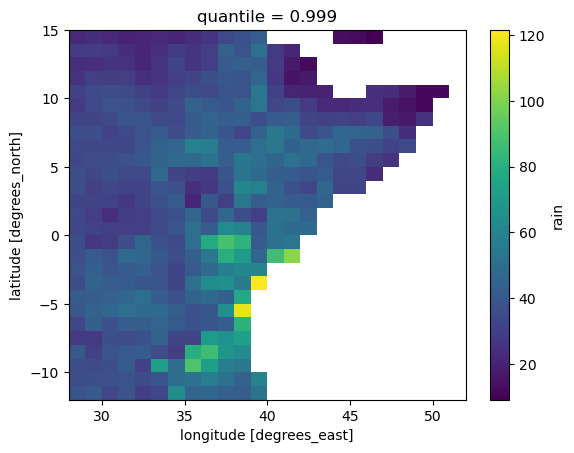

In [38]:
ds_chirps.rain.sel(    lon=slice(28, 52),
    lat=slice(-12, 15)).quantile(.999, 'time').plot()

In [40]:
ea_mean = ds_chirps.rain.sel(
    lon=slice(28, 52),
    lat=slice(-12, 20)
).weighted(np.cos(np.deg2rad(ds_chirps.lat))).mean(dim=["lat", "lon"])

ea_mean.to_netcdf('/Data/gfi/users/rogui7909/data/AfricaPrecip/features/EastAfrica_mean_CHIRPS.nc')
